In [2]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROUND_NUM = 3
BASE = '.'
DAYS = ['0', '1', '2']

# Load all price data
frames = []
trade_frames = []
for day in DAYS:
    df = pd.read_csv(f'{BASE}/round3/prices_round_{ROUND_NUM}_day_{day}.csv', sep=';')
    trade_df = pd.read_csv(f'{BASE}/round3/trades_round_{ROUND_NUM}_day_{day}.csv', sep=';')
    
    df['abs_ts'] = df['timestamp'] + int(day) * 1_000_000
    trade_df['abs_ts'] = trade_df['timestamp'] + int(day) * 1_000_000
    trade_df['day'] = int(day)
    frames.append(df)
    trade_frames.append(trade_df)

prices = pd.concat(frames, ignore_index=True)
trades = pd.concat(trade_frames, ignore_index=True)

products = sorted(prices['product'].unique())
print(f'Products: {products}')
print(f'Days: {DAYS}  |  Total rows: {len(prices)}')

Products: ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']
Days: ['0', '1', '2']  |  Total rows: 360000


In [3]:
pack = prices[prices['product'] == "HYDROGEL_PACK"]
pack_trades = trades[trades['symbol'] == 'HYDROGEL_PACK']

In [4]:
pack.head(3)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,abs_ts
7,0,0,HYDROGEL_PACK,9992,15,9990.0,30.0,NaN,NaN,10008,15,10010.0,30.0,NaN,NaN,10000.0,0.0,0
19,0,100,HYDROGEL_PACK,9992,13,9990.0,30.0,NaN,NaN,10008,13,10011.0,30.0,NaN,NaN,10000.0,0.0,100
24,0,200,HYDROGEL_PACK,9995,13,9992.0,21.0,NaN,NaN,10011,13,10013.0,21.0,NaN,NaN,10003.0,0.0,200


In [5]:
pack_trades

,timestamp,buyer,seller,symbol,currency,price,quantity,abs_ts,day
7,8000,NaN,NaN,HYDROGEL_PACK,XIRECS,10018.0,6,8000,0
10,10100,NaN,NaN,HYDROGEL_PACK,XIRECS,10014.0,5,10100,0
18,15300,NaN,NaN,HYDROGEL_PACK,XIRECS,10026.0,3,15300,0
20,15700,NaN,NaN,HYDROGEL_PACK,XIRECS,10009.0,2,15700,0
21,16400,NaN,NaN,HYDROGEL_PACK,XIRECS,10009.0,4,16400,0
...,...,...,...,...,...,...,...,...,...
4029,984700,NaN,NaN,HYDROGEL_PACK,XIRECS,9984.0,5,2984700,2
4033,992200,NaN,NaN,HYDROGEL_PACK,XIRECS,10029.0,4,2992200,2
4035,993200,NaN,NaN,HYDROGEL_PACK,XIRECS,10024.0,6,2993200,2
4042,994800,NaN,NaN,HYDROGEL_PACK,XIRECS,10011.0,4,2994800,2


In [6]:
pack['mid_price'].mean()

np.float64(9990.806866666666)

In [7]:
pack_trades['timestamp'].value_counts()
# pack_trades[pack_trades['abs_ts'] == 596100]
# pack_trades[pack_trades['timestamp'] == 502000]
# pack_trades[pack_trades['timestamp'] == 501600]
# 501400    2
# 206200    2

timestamp
596100    2
502000    2
501600    2
501400    2
206200    2
         ..
65400     1
65900     1
69500     1
73500     1
40900     1
Name: count, Length: 986, dtype: int64

In [8]:
pack['fair'] = pack['mid_price'] * 0.9 + 0.1 * 9990

/tmp/ipykernel_24189/2402691524.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pack['fair'] = pack['mid_price'] * 0.9 + 0.1 * 9990


/tmp/ipykernel_24189/229194468.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pack['spread'] = pack['ask_price_1'] - pack['bid_price_1']


(array([  275.,   490.,   225.,     0.,     0.,     0.,     0.,     0.,
          798., 28212.]),
 array([ 7.,  8.,  9., 10., 11., 12., 13., 14., 15., 16., 17.]),
 <BarContainer object of 10 artists>)

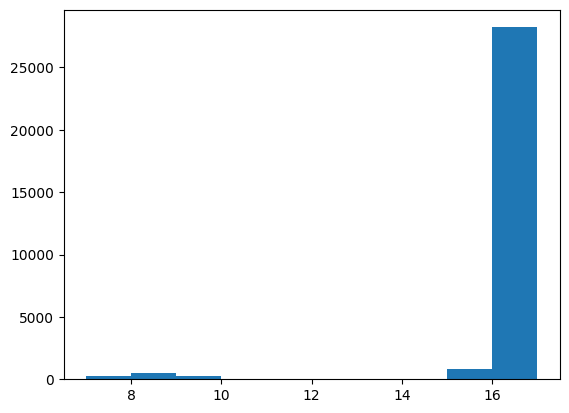

In [12]:
pack['spread'] = pack['ask_price_1'] - pack['bid_price_1']
plt.hist(pack['spread'])

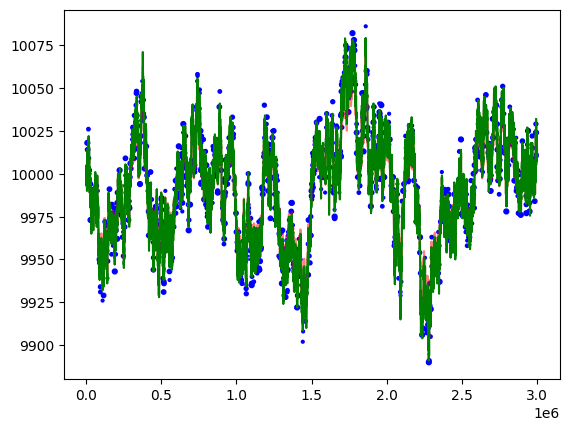

In [10]:
plt.plot(pack['abs_ts'], pack['fair'], color="red", alpha=0.5)
plt.plot(pack['abs_ts'], pack['mid_price'], color="green")
plt.scatter(pack_trades['abs_ts'], pack_trades['price'], s=2 * pack_trades['quantity'], c="blue")

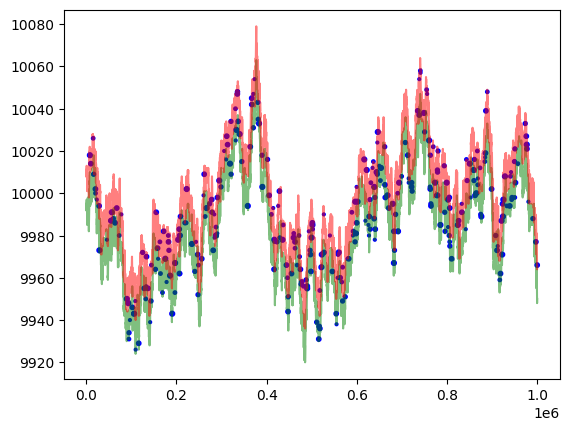

In [11]:
day1_pack = pack[pack['day'] == 0]
day1_trades = pack_trades[pack_trades['day'] == 0]

plt.plot(day1_pack['abs_ts'], day1_pack['bid_price_1'], color="green", alpha=0.5)
plt.plot(day1_pack['abs_ts'], day1_pack['ask_price_1'], color="red", alpha=0.5)
plt.scatter(day1_trades['abs_ts'], day1_trades['price'], s=2 * day1_trades['quantity'], c="blue")